# Analysis

## imports

In [66]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
import sys
import os
sys.path.append(f'{os.getcwd()}/irc_gym')

In [68]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from auditoryforage.utils import plot_AF_episode
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel
from multiprocessing import Pool
import multiprocess as mp
import multiprocess
from ult import *

In [110]:
np.random.choice([0,1,2,3])

3

## settings

In [94]:
# template for training
print('''
    date 5.6
    goal:
      nice periodic,
    new: 
        linear 56
        use the env param that generate good peroid the first time
    comments:
    some nice gradient plots. some opposite result for the attn vs sig prob plot. coudl because the cost of attn > lick?
''')
# training hyper params
epoch_size = 15000
eval_size = 700
n_epoch = 80
n_seed=1
p1p2=np.array([0.5,0.6])
p1p2=None

# reward list
vmin, vmax=100,10000
food_reward_list = np.linspace(vmin, vmax, 9)
# food_reward_list=np.exp(food_reward_list)

print('food reard list: ', [f'{a:.0f}' for a in food_reward_list])

# other env params
env_param = [-10, 1500, 0.087213, .25, -50, 0, 0]
#
modelname='confirm56again_0'
epochname=30


    date 5.6
    goal:
      nice periodic,
    new: 
        linear 56
        use the env param that generate good peroid the first time
    comments:
    some nice gradient plots. some opposite result for the attn vs sig prob plot. coudl because the cost of attn > lick?

food reard list:  ['100', '1338', '2575', '3812', '5050', '6288', '7525', '8762', '10000']


In [95]:
food_reward_list = np.linspace(10, 5000, 5)

In [96]:
seed=0
agent=PPO.load(f'ycstore/seed_{seed}_{modelname}_epoch_{epochname}', device='cpu')
# agent=PPO.load(f'ycstore/15thcheckpoint', device='cpu')

task = AFR2(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
num_epochs = 1
task.food_reward_list = food_reward_list

taskbelief = FuncBeliefModel(env=task, rng=1)

no_episodes = 2222

## collect data

In [97]:
# collect trial data
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=agent,
                              num_steps=100000, deterministic=True)
    return episode

with multiprocess.Pool(processes=6) as pool:
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))

In [98]:
# process trial data
def process_one_episode_wrapper(episode):
    return process_one_episode(episode, task)
with mp.Pool(processes=6) as pool:
    results = pool.map(process_one_episode_wrapper, all_episode_data)

## process data

In [99]:

# process the mp results
hit_count_list = [[0] for _ in range(len(food_reward_list))]
miss_count_list = [[0] for _ in range(len(food_reward_list))]
false_alarm_list = [[0] for _ in range(len(food_reward_list))]

noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
total_signal_time_list = [[0] for _ in range(len(food_reward_list))]

# dist naming space: list of list of num. big list of each reward cond. small list of each trial's summary stats, which is a single number.
total_reward_dist= [[] for _ in range(len(food_reward_list))]
rt_hit_dist=[[] for _ in range(len(food_reward_list))]
rt_fa_dist=[[] for _ in range(len(food_reward_list))]
total_att_time_dist = [[] for _ in range(len(food_reward_list))]
for res in results:
    (food_reward_idx,
     hit_count,
     miss_count,
     false_alarm_count,

     noise_time_before_lick,
     signal_time_before_lick,
     total_noise_time,
     total_signal_time,

     total_reward,

     attention_time_points_across_episodes,
     episode_length_across_episodes,
     hit_reaction_time_across_episodes,
     fa_reaction_time_across_episodes
     ) = res

    hit_count_list[food_reward_idx][0] += (hit_count)
    miss_count_list[food_reward_idx][0] += (miss_count)
    false_alarm_list[food_reward_idx][0] += (false_alarm_count)

    noise_time_before_lick_list[food_reward_idx][0] += (noise_time_before_lick)
    signal_time_before_lick_list[food_reward_idx][0] += (
        signal_time_before_lick)
    total_noise_time_list[food_reward_idx][0] += (total_noise_time)
    total_signal_time_list[food_reward_idx][0] += (total_signal_time)

    total_reward_dist[food_reward_idx].append(total_reward)
    rt_hit_dist[food_reward_idx].append(signal_time_before_lick)
    rt_fa_dist[food_reward_idx].append(noise_time_before_lick)
    total_att_time_dist[food_reward_idx].append(len(attention_time_points_across_episodes[0]))

In [100]:
# process the data. this is slow.
all_reward_res={} # k: v = foodreward idx: this food reward res
for r in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
    all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len


for episode in all_episode_data[:100]:
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
 
    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))
    else:
        lick_time_list.append(None)
    trial_len.append(len(episode['actions']))

In [101]:
notify('analysis plot ready!')

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1201/1465457985.py:68: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix,1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1201/1465457985.py:68: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix,1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_1201/1465457985.py:68: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_metric_matrix,1)
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWa

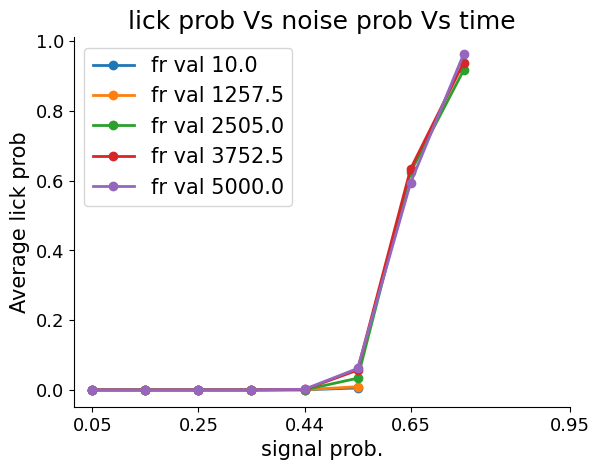

In [105]:
title = 'lick entropy Vs noise prob Vs time'
# title='att entropy Vs noise prob Vs time'
title = 'att prob Vs noise prob Vs time'
title = 'lick prob Vs noise prob Vs time'


def compute_bernoulli_entropy(prob_list):
    entropy_list = [- p * np.log(p) - (1-p) * np.log(1-p) for p in prob_list]
    return entropy_list

plt.figure()
    
plot_num_episodes=100


for trial_food_reward_idx in range(len(food_reward_list)):
    attention_entropy_list,lick_entropy_list,    attention_prob_list,    lick_prob_list,    noise_prob_list,    attention_entropy_list = [],[],[],[],[],[]
    ep_no=0
    while len(attention_entropy_list)<plot_num_episodes and ep_no<len(all_episode_data):
        episode=all_episode_data[ep_no]
        if episode['trial_food_reward_idx']==trial_food_reward_idx:
            attention_prob, lick_prob, noise_prob, time = get_att_lick_probs_new(episode, agent)
            attention_prob_list.append(attention_prob)
            lick_prob_list.append(lick_prob)
            noise_prob_list.append(noise_prob)
            attention_entropy_list.append(compute_bernoulli_entropy(attention_prob))
            lick_entropy_list.append(compute_bernoulli_entropy(lick_prob))
        ep_no+=1


    if title == 'att prob Vs noise prob Vs time':
        data = (attention_prob_list, noise_prob_list)
    elif title == 'lick prob Vs noise prob Vs time':
        data = (lick_prob_list, noise_prob_list)
    elif title == 'att entropy Vs noise prob Vs time':
        data = (attention_entropy_list, noise_prob_list)
    elif title == 'lick entropy Vs noise prob Vs time':
        data = (lick_entropy_list, noise_prob_list)
    else:
        print('Error: Change title!')


    if title in ['att prob Vs noise prob Vs time', 'lick prob Vs noise prob Vs time','att entropy Vs noise prob Vs time','lick entropy Vs noise prob Vs time']:
        no_ticks = 5
        no_prob_bins = 10
        min_display_time = 0
        max_display_time = 50
        prob_bin_vals = np.linspace(1/(2*no_prob_bins),1-1/(2*no_prob_bins),no_prob_bins)
        display_tick_inds = np.linspace(0,len(prob_bin_vals) - 1,no_ticks).astype(int)
        
        (metric_list, noise_prob_list) = data
        max_time = max([len(metric_val) for metric_val in metric_list])

        prob_dict = {}
        for episode_ind in range(len(noise_prob_list)):
            for time_ind in range(len(noise_prob_list[episode_ind])):
                prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)),time_ind), []).append(metric_list[episode_ind][time_ind])
        
        avg_metric_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
        sem_metric_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
        count_matrix = np.full((no_prob_bins + 1, max_time), 0.0)
        for (noise_prob_bin, time_ind), metric_list in prob_dict.items():
            avg_metric_matrix[noise_prob_bin,time_ind] = np.mean(metric_list)
            sem_metric_matrix[noise_prob_bin,time_ind] = np.std(metric_list)/np.sqrt(len(metric_list))
            count_matrix[noise_prob_bin,time_ind] = len(metric_list)


        mean_list = np.nanmean(avg_metric_matrix,1)
        sample_size_list = np.sum(count_matrix,1)
        sem_list = np.nanstd(avg_metric_matrix,1)/np.sqrt(sample_size_list)
        
        
        # plt.errorbar([ind for ind in range(len(mean_list))], mean_list[::-1], yerr= sem_list[::-1], fmt='o', markersize=6, capsize=4)
        plt.plot(mean_list[::-1], 'o-',label = f'fr val {food_reward_list[trial_food_reward_idx]}')
        
        
        plt.xlabel('signal prob.')
        if title == 'att prob Vs noise prob Vs time':
            plt.ylabel('Average att prob')
        elif title == 'lick prob Vs noise prob Vs time':
            plt.ylabel('Average lick prob')
        plt.xticks(display_tick_inds,[str(prob_bin_vals[ind])[:4] for ind in display_tick_inds])
        plt.xlabel('signal prob.')
plt.title(title)    
plt.legend()
plt.show()

# example saves

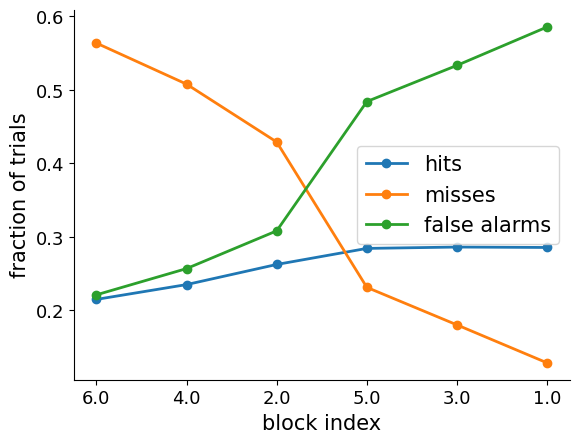

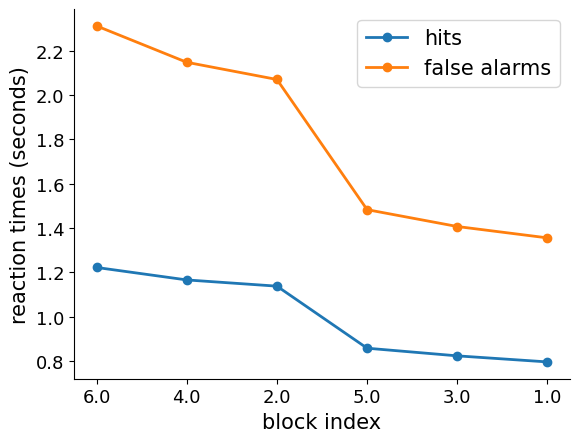

In [108]:
from auditoryforage.utils import open_pickle_file
metrics_across_blocks = open_pickle_file('/Users/yc/Downloads/metrics_across_blocks.pkl')

one_sec_in_node_units = task.no_signal_nodes/3 #3s being signal duration

metrics = ['hits_per_trial', 'misses_per_trial', 'FAs_per_trial']
block_indices_list = ['6.0', '4.0', '2.0', '5.0', '3.0', '1.0']
plt.figure()
for metric in metrics:
    mean_list = [np.mean(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
    sem_list = [np.std(metrics_across_blocks[block_ind][metric])/np.sqrt(len(metrics_across_blocks[block_ind][metric])) for block_ind in block_indices_list]
    plt.plot(np.arange(len(block_indices_list)), mean_list,'-o')
plt.xlabel('block index')
plt.ylabel('fraction of trials')
plt.legend(['hits', 'misses', 'false alarms'])
plt.xticks(np.arange(len(block_indices_list)),block_indices_list)  # Set x-axis labels to column indices
plt.show()

metrics = ['hit_reaction_time_list','fa_reaction_time_list']
block_indices_list = ['6.0', '4.0', '2.0', '5.0', '3.0', '1.0']
plt.figure()
for metric in metrics:
    mean_list = [1/one_sec_in_node_units * np.mean(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
    sem_list = [np.std(metrics_across_blocks[block_ind][metric])/np.sqrt(len(metrics_across_blocks[block_ind][metric])) for block_ind in block_indices_list]
    plt.plot(np.arange(len(block_indices_list)), mean_list,'-o')
plt.xlabel('block index')
plt.ylabel('reaction times (seconds)')
plt.legend(['hits', 'false alarms'])
plt.xticks(np.arange(len(block_indices_list)),block_indices_list)  # Set x-axis labels to column indices
plt.show()

In [ ]:
prob_dict = {}
for noisep_ep in noise_prob_list:
    for t,v in noisep_ep:
        prob_dict.setdefault((int(np.floor(v*no_prob_bins)), t)).append()

In [44]:
len(metric_list), len(noise_prob_list)

(100, 400)

In [39]:
(int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)),time_ind), [], (episode_ind,len(metric_list),len(noise_prob_list)), time_ind,len(metric_list[0])

# (metric_list[episode_ind][time_ind])
# append(metric_list[episode_ind][time_ind])



((10, 0), [], (100, 100, 400), 0, 68)

# plots

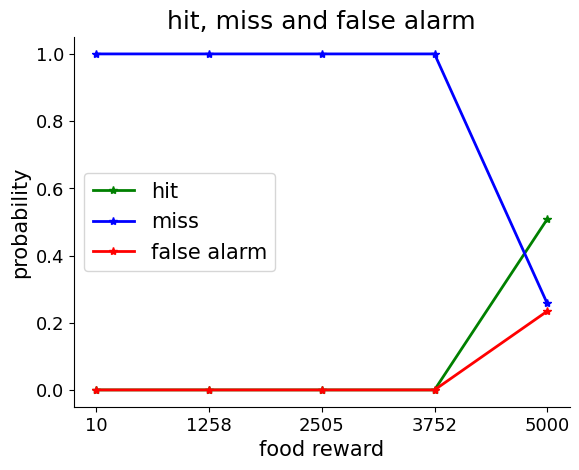

In [49]:
# figure 1
#n classic 3 color curve.
f=plot_hit_miss_FA(food_reward_list, hit_count_list, miss_count_list, false_alarm_list, 'hit, miss and false alarm')
quicksave('hit and fa',modelname, fig=f)

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_50949/739333290.py:3: RuntimeWarning: invalid value encountered in divide
  v = (v - min(v)) / (max(v) - min(v))
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_50949/739333290.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(v, fill=False, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=0.5,)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_50949/739333290.py:3: RuntimeWarning: invalid value encountered in divide
  v = (v - min(v)) / (max(v) - min(v))
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_50949/739333290.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(v, fill=False, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=0.5,)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T

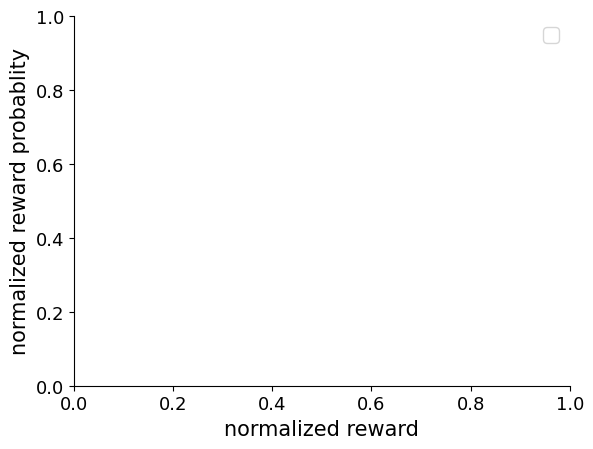

In [24]:
# figure 3, food reward distribution
for food_reward_idx, v in enumerate(total_reward_dist):
    v = (v - min(v)) / (max(v) - min(v))
    v = 1-v
    sns.kdeplot(v, fill=False, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=0.5,)
plt.ylabel('normalized reward probablity')
plt.xlabel('normalized reward')
plt.legend()
quicksave('reward distribution', modelname)
plt.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_50949/3702327053.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}',
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_50949/3702327053.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}',
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_50949/3702327053.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}',
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_50949/3702327053.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=Fal

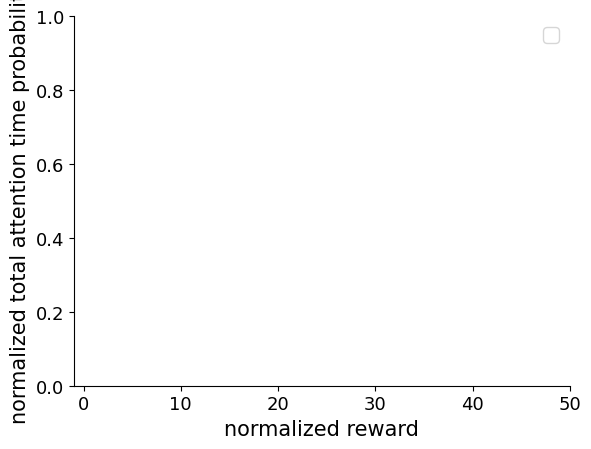

In [25]:
# figure 4
# total attention time in one trial distubition, similar to the reward distribution during training

for food_reward_idx, v in enumerate(total_att_time_dist):
    v = np.array(v)
    # ignore the 0 reaction time in the plots
    sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', 
                clip=(0, np.max(v)), 
                bw_adjust=2
                )
plt.xlim(-1,50)
plt.ylabel('normalized total attention time probability')
plt.xlabel('normalized reward')
plt.legend()
quicksave('attn time distribution', modelname)
plt.show()

 

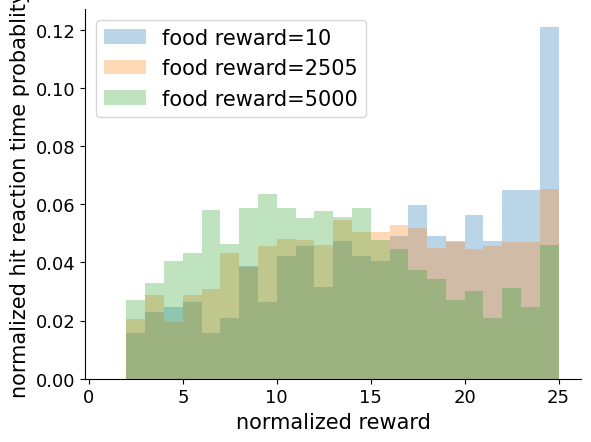

In [ ]:

# figure 5
# reaction time distubition, similar to the reward distribution during training
for food_reward_idx, v in enumerate(rt_hit_dist):
    if food_reward_idx in [0,2,4]:
        v=np.array(v)
        v=v[v>1]
        # ignore the 0 reaction time in the plots
        _=plt.hist(v, bins=np.arange(1, np.max(v) + 1), density=True, alpha=0.3, label=f'food reward={food_reward_list[food_reward_idx]:.0f}',)
plt.ylabel('normalized hit reaction time probablity')
plt.xlabel('normalized reward')
plt.legend()
quicksave('reaction time distribution v2', modelname)
plt.show()

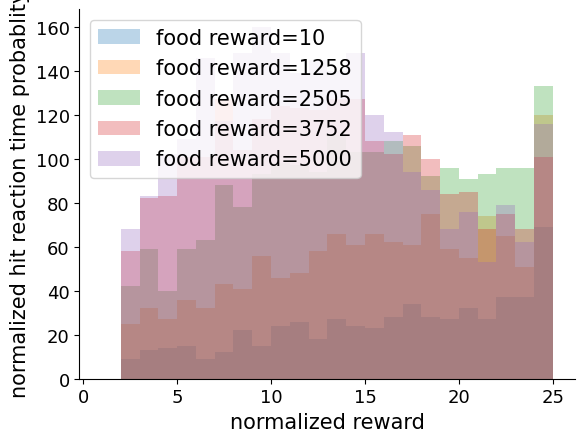

In [ ]:

# figure 5
# reaction time distubition, similar to the reward distribution during training
for food_reward_idx, v in enumerate(rt_hit_dist):
    v=np.array(v)
    v=v[v>1]
    # ignore the 0 reaction time in the plots
    _=plt.hist(v, bins=np.arange(1, np.max(v) + 1), density=False, alpha=0.3, label=f'food reward={food_reward_list[food_reward_idx]:.0f}',)
plt.ylabel('normalized hit reaction time probablity')
plt.xlabel('normalized reward')
plt.legend()
plt.show()


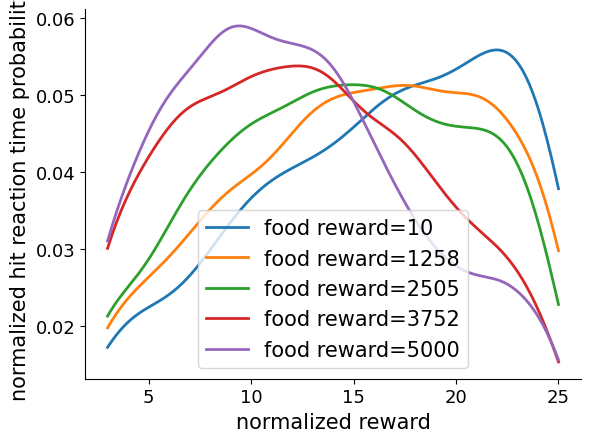

In [ ]:
# alt
for food_reward_idx, v in enumerate(rt_hit_dist):
    v = np.array(v)
    v=v[v>1]
    # ignore the 0 reaction time in the plots
    sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', clip=(3, np.max(v)), bw_adjust=1, common_norm=True)
plt.ylabel('normalized hit reaction time probability')
plt.xlabel('normalized reward')
plt.legend()
quicksave('reaction time distribution v3 full', modelname)
plt.show()



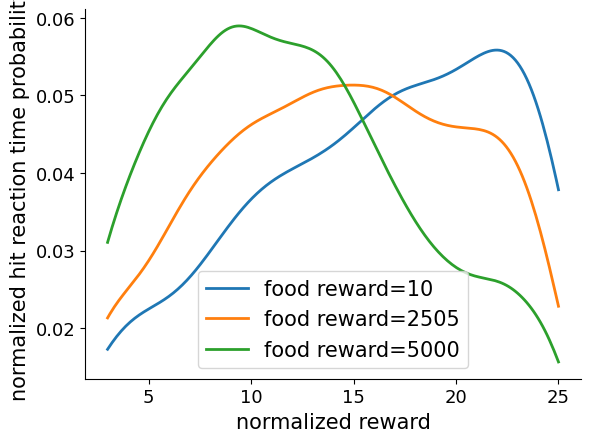

In [ ]:
for food_reward_idx, v in enumerate(rt_hit_dist):
    if food_reward_idx in [0,2,4]:
        v = np.array(v)
        v=v[v>1]
        # ignore the 0 reaction time in the plots
        sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', clip=(3, np.max(v)), bw_adjust=1, common_norm=True)
plt.ylabel('normalized hit reaction time probability')
plt.xlabel('normalized reward')
plt.legend()
quicksave('reaction time distribution v3', modelname)
plt.show()

## falase alarm reaction time
# for food_reward_idx, v in enumerate(rt_fa_dist):
#     v=np.array(v)
#     _=plt.hist(v, bins=np.arange(1, np.max(v) + 1), density=True, alpha=0.3, label=f'food reward={food_reward_list[food_reward_idx]:.0f}',)
# plt.ylabel('normalized fa reaction time probablity')
# plt.xlabel('normalized reward')
# plt.legend()
# plt.show()


# # alt
# for food_reward_idx, v in enumerate(rt_fa_dist):
#     v = np.array(v)
#     # ignore the 0 reaction time in the plots
#     sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', clip=(3, np.max(v)), bw_adjust=0.5)

# plt.ylabel('normalized hit reaction time probability')
# plt.xlabel('normalized reward')
# plt.legend()
# plt.show()


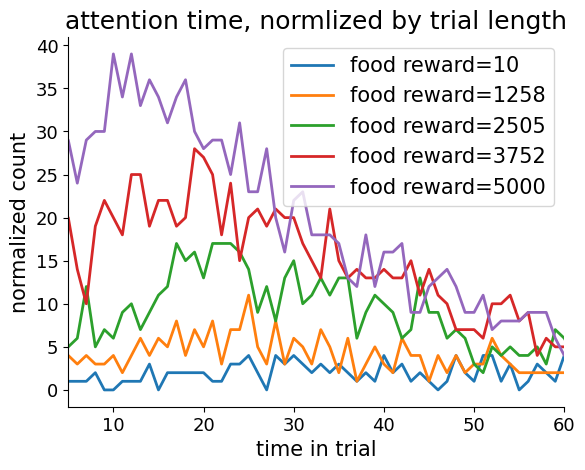

In [ ]:
# added may1st, figure 6
plt.figure()
for food_reward_idx in all_reward_res.keys():
    
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]

    data=att_time_list        
    padded=pad_zero_attention(data)
    trial_count_i=count_less_equal_index(trial_len)
    
    # plt.plot(np.sum(padded, axis=0)*np.cumsum(trial_count_i))
    plt.plot(np.sum(padded, axis=0),label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
    # plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)), label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
plt.xlabel('time in trial')
plt.ylabel('normalized count')
plt.title(f'attention time, normlized by trial length')
# plt.ylim(0,1500)
plt.xlim(5,60)
plt.legend()
plt.show()

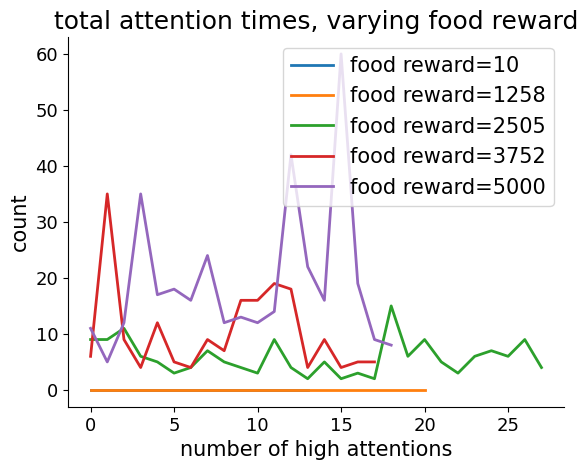

In [116]:
# added may1st, figure 6
plt.figure()
for food_reward_idx in all_reward_res.keys():
    
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]

    
    # plt.hist([len(a) for a in att_time_list],label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
    sns.kdeplot([len(a) for a in att_time_list],label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=3)

plt.xlabel('number of high attentions')
plt.ylabel('count')
plt.title(f'total attention times, varying food reward')
# plt.ylim(0,1500)
# plt.xlim(5,60)
plt.legend()
plt.show()

In [ ]:
# # added may1st, figure 6
# for food_reward_idx in all_reward_res.keys():
    
#     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]

#     data=att_time_list        
#     padded=pad_zero_attention(data)
#     trial_count_i=count_less_equal_index(trial_len)
#     plt.figure()
#     # plt.plot(np.sum(padded, axis=0)*np.cumsum(trial_count_i))
#     # plt.plot(np.sum(padded, axis=0)/(trial_count_i))
#     # plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)))
#     plt.plot(np.sum(padded, axis=0))
#     plt.xlabel('time in trial')
#     plt.ylabel('normalized count')
#     plt.title(f'attention time, normlized by trial length\nfood_reward={food_reward_list[food_reward_idx]:.0f}')
#     plt.show()

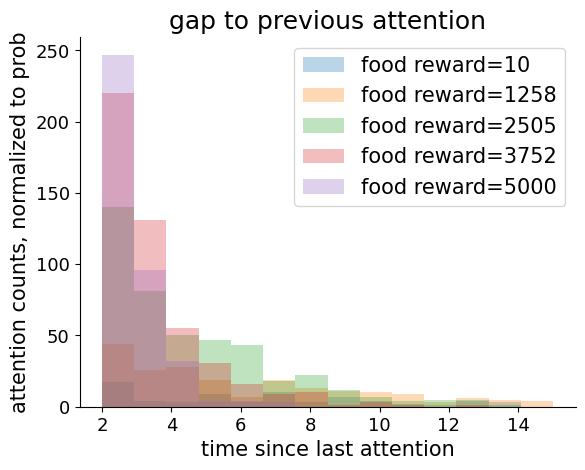

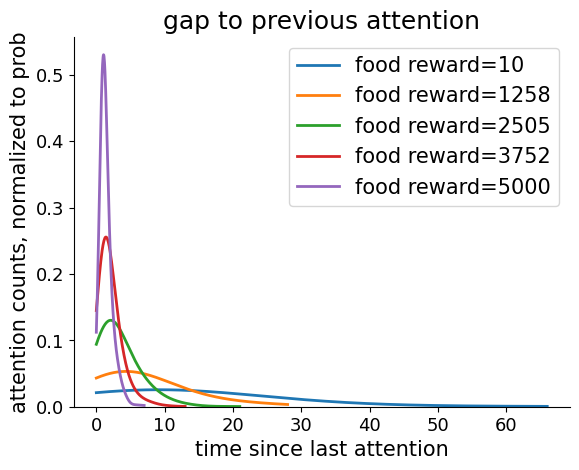

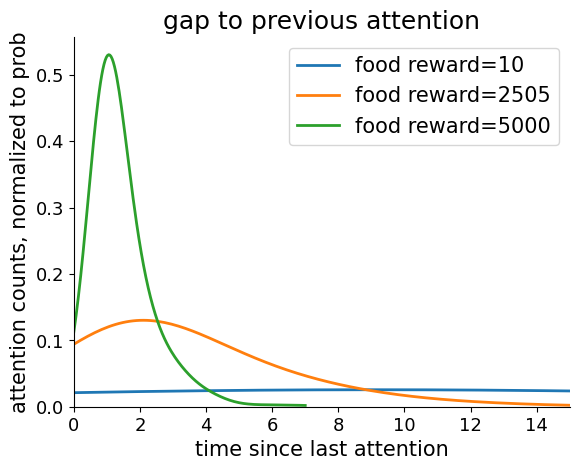

In [ ]:
# figure 7
# for food_reward_idx, v in all_reward_res.items():
#     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
#     att_size_previous=[previous_block_size(a) for a in att_time_list]
#     a=np.concatenate(att_size_previous)
#     plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=True,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
#     # sns.kdeplot(a, fill=False, bw_adjust=0.5)
# plt.ylim(0,1)
# plt.title('previous attention block size')
# plt.ylabel('attention counts, normalized to prob')
# plt.xlabel('previous attention block size')
# plt.legend()
# plt.show()

for food_reward_idx, v in all_reward_res.items():
    # if food_reward_idx in [3,4]:
        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
        att_gap2previous=[previous_item_gap(a) for a in att_time_list]
        a=np.concatenate(att_gap2previous)
        plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=False,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
        # sns.kdeplot(a, fill=False, bw_adjust=0.5)
# plt.ylim(0,1)
plt.title('gap to previous attention')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('time since last attention')
plt.legend()
plt.show()

for food_reward_idx, v in all_reward_res.items():
    # if food_reward_idx in [3,4]:
        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
        att_gap2previous=[previous_item_gap(a) for a in att_time_list]
        a=np.concatenate(att_gap2previous)
        a=a[a>0]
        # plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=False,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
        sns.kdeplot(a, fill=False,clip=(0, np.max(a)), bw_adjust=3,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
# plt.ylim(0,1)
plt.title('gap to previous attention')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('time since last attention')
plt.legend()
quicksave('gap full', modelname)
plt.show()

for food_reward_idx, v in all_reward_res.items():
    if food_reward_idx in [0,2,4]:
        attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
        att_gap2previous=[previous_item_gap(a) for a in att_time_list]
        a=np.concatenate(att_gap2previous)
        a=a[a>0]
        # plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=False,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
        sns.kdeplot(a, fill=False, clip=(0, np.max(a)),bw_adjust=3,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
plt.xlim(0,15)
plt.title('gap to previous attention')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('time since last attention')
plt.legend()
quicksave('gap', modelname)
plt.show()

In [ ]:
# # fig 7 alt
# for food_reward_idx, v in all_reward_res.items():
#     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=v
#     att_size_previous=[previous_block_size(a) for a in att_time_list]
#     att_gap2previous=[previous_item_gap(a, remove_first=False) for a in att_time_list]
#     plt.scatter(np.concatenate(att_gap2previous), np.concatenate(att_size_previous), alpha=0.01, s=1, color='k')
# plt.ylabel('previous attention block size')
# plt.xlabel('time since last attention')
# plt.show()


/tmp/ipykernel_2285224/3783445583.py:30: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_action_prob_matrix,1)
/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


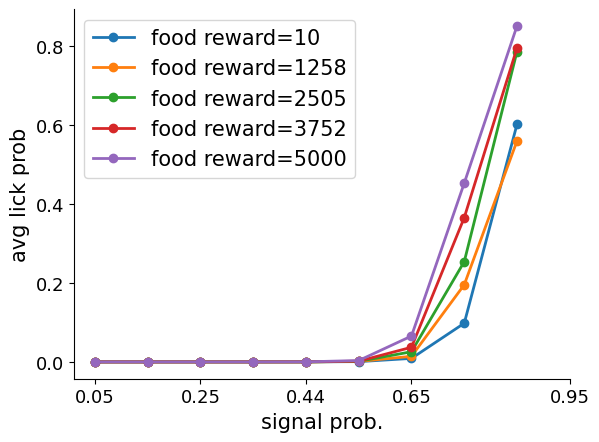

In [ ]:
# signal prob --> lick
for food_reward_idx in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]

    no_ticks = 5
    no_prob_bins = 10
    min_display_time = 0
    max_display_time = 50
    prob_bin_vals = np.linspace(1/(2*no_prob_bins),1-1/(2*no_prob_bins),no_prob_bins)
    display_tick_inds = np.linspace(0,len(prob_bin_vals) - 1,no_ticks).astype(int)

    # (action_prob_list, noise_prob_list) = (attention_prob_list, noise_prob_list)
    (action_prob_list, noise_prob_list) = (lick_prob_list, noise_prob_list)
    max_time = max([len(action_prob) for action_prob in action_prob_list])

    prob_dict = {}
    for episode_ind in range(len(noise_prob_list)):
        for time_ind in range(len(noise_prob_list[episode_ind])):
            prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)),time_ind), []).append(action_prob_list[episode_ind][time_ind])

    avg_action_prob_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
    sem_action_prob_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
    count_matrix = np.full((no_prob_bins + 1, max_time), 0.0)
    for (noise_prob_bin, time_ind), action_prob_list in prob_dict.items():
        avg_action_prob_matrix[noise_prob_bin,time_ind] = np.mean(action_prob_list)
        sem_action_prob_matrix[noise_prob_bin,time_ind] = np.std(action_prob_list)/np.sqrt(len(action_prob_list))
        count_matrix[noise_prob_bin,time_ind] = len(action_prob_list)


    mean_list = np.nanmean(avg_action_prob_matrix,1)
    sample_size_list = np.sum(count_matrix,1)
    sem_list = np.nanstd(avg_action_prob_matrix,1)/np.sqrt(sample_size_list)


    # plt.errorbar([ind for ind in range(len(mean_list))], mean_list[::-1], yerr= sem_list[::-1], fmt='o', markersize=6, capsize=4)
    plt.plot(mean_list[::-1], 'o-', label=f'food reward={food_reward_list[food_reward_idx]:.0f}')


plt.xticks(display_tick_inds,[str(prob_bin_vals[ind])[:4] for ind in display_tick_inds])
plt.xlabel('signal prob.')
plt.ylabel('avg lick prob')
quicksave('signal prob to lick', modelname)
plt.legend()

/tmp/ipykernel_2285224/877871723.py:30: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_action_prob_matrix,1)
/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


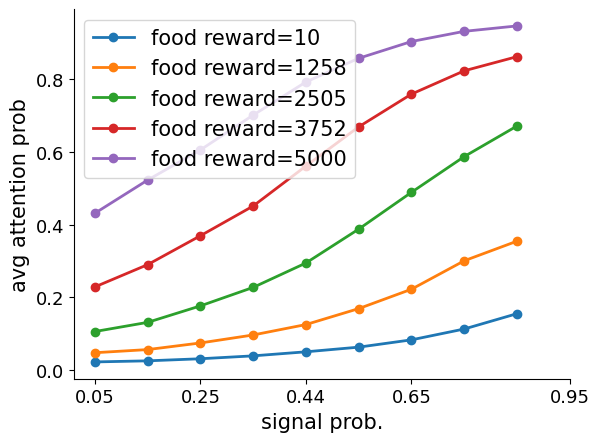

In [ ]:
# signal prob to attn
for food_reward_idx in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]

    no_ticks = 5
    no_prob_bins = 10
    min_display_time = 0
    max_display_time = 50
    prob_bin_vals = np.linspace(1/(2*no_prob_bins),1-1/(2*no_prob_bins),no_prob_bins)
    display_tick_inds = np.linspace(0,len(prob_bin_vals) - 1,no_ticks).astype(int)

    (action_prob_list, noise_prob_list) = (attention_prob_list, noise_prob_list)
    # (action_prob_list, noise_prob_list) = (lick_prob_list, noise_prob_list)
    max_time = max([len(action_prob) for action_prob in action_prob_list])

    prob_dict = {}
    for episode_ind in range(len(noise_prob_list)):
        for time_ind in range(len(noise_prob_list[episode_ind])):
            prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)),time_ind), []).append(action_prob_list[episode_ind][time_ind])

    avg_action_prob_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
    sem_action_prob_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
    count_matrix = np.full((no_prob_bins + 1, max_time), 0.0)
    for (noise_prob_bin, time_ind), action_prob_list in prob_dict.items():
        avg_action_prob_matrix[noise_prob_bin,time_ind] = np.mean(action_prob_list)
        sem_action_prob_matrix[noise_prob_bin,time_ind] = np.std(action_prob_list)/np.sqrt(len(action_prob_list))
        count_matrix[noise_prob_bin,time_ind] = len(action_prob_list)


    mean_list = np.nanmean(avg_action_prob_matrix,1)
    sample_size_list = np.sum(count_matrix,1)
    sem_list = np.nanstd(avg_action_prob_matrix,1)/np.sqrt(sample_size_list)


    # plt.errorbar([ind for ind in range(len(mean_list))], mean_list[::-1], yerr= sem_list[::-1], fmt='o', markersize=6, capsize=4)
    plt.plot(mean_list[::-1], 'o-', label=f'food reward={food_reward_list[food_reward_idx]:.0f}')


plt.xticks(display_tick_inds,[str(prob_bin_vals[ind])[:4] for ind in display_tick_inds])
plt.xlabel('signal prob.')
plt.ylabel('avg attention prob')
quicksave('signal prob to attn', modelname)
plt.legend()

In [ ]:
# # heatmap trial indicator (att only)
# plot_no_episodes=100

# for food_reward_idx in (all_reward_res.keys()):
#     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
#     sortind=np.argsort(trial_len[:plot_no_episodes])

#     # attn
#     plot_data =att_time_list[:plot_no_episodes]
#     plt.figure()
#     c=plt.imshow(pad_zero_attention(plot_data)[sortind], cmap='viridis',
#                     aspect='auto', interpolation='none')
#     plt.colorbar(c)
#     plt.xlabel('time in trial')
#     plt.ylabel('episode no.')
#     plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')
#     plt.show()

#     # # lick
#     # plot_data =lick_time_list[:plot_no_episodes]
#     # plt.figure()
#     # c=plt.imshow(pad_zero_attention(plot_data)[sortind], cmap='viridis',
#     #                 aspect='auto', interpolation='none')
#     # plt.colorbar(c)
#     # plt.xlabel('time in trial')
#     # plt.ylabel('episode no.')
#     # plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')
#     # plt.show()

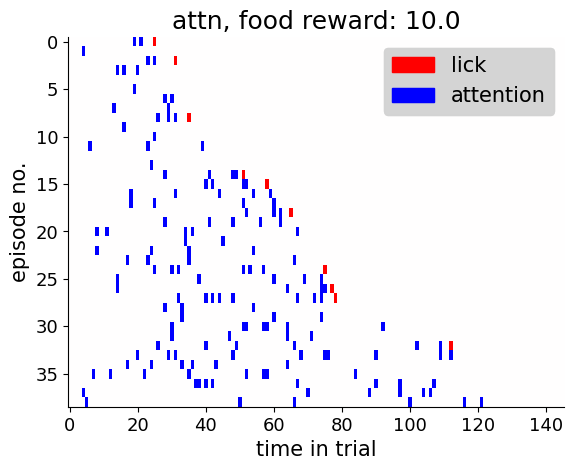

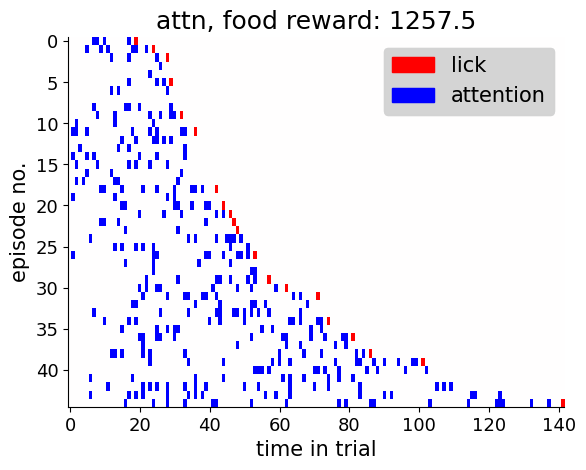

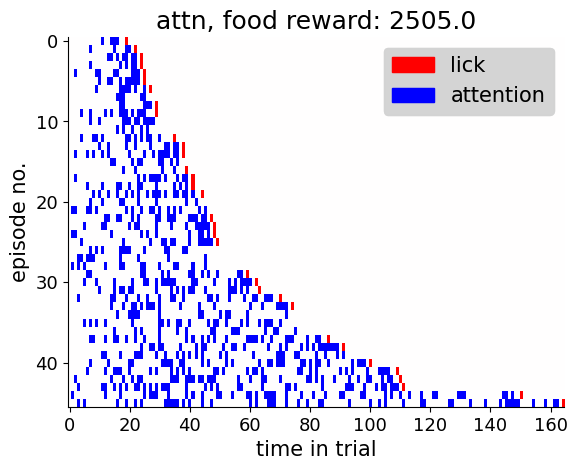

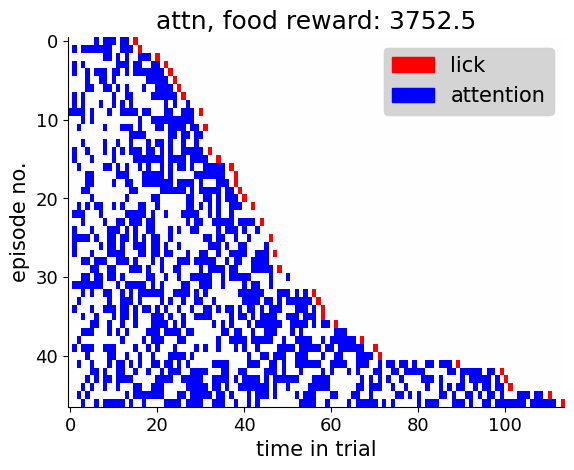

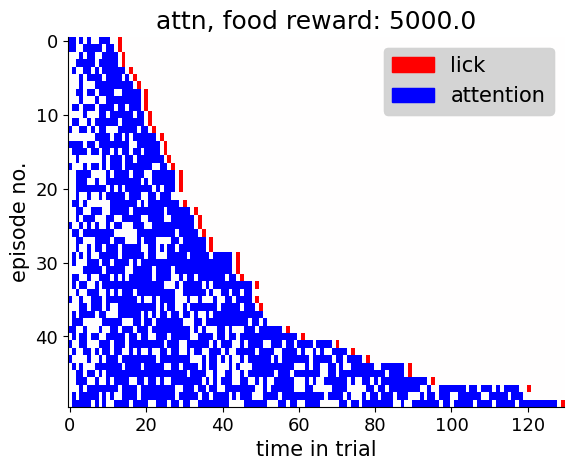

In [ ]:
# heatmap trial indicator (att and lick)
plot_no_episodes=100

for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
    sortind=np.argsort(trial_len[:plot_no_episodes])

    grid = np.zeros((plot_no_episodes, max(trial_len)+2))

    # att
    plot_data =att_time_list[:plot_no_episodes]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data =lick_time_list[:plot_no_episodes]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    
    plt.figure()
    c=plt.imshow(grid[sortind], cmap='bwr', vmin=-1, vmax=1,
                    aspect='auto', interpolation='none')
    # plt.colorbar(c)
    plt.xlabel('time in trial')
    plt.ylabel('episode no.')
    plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

    # legend
    from matplotlib.patches import Patch

    # Create Patch objects for the custom legend
    red_patch = Patch(color='red', label='lick')
    blue_patch = Patch(color='blue', label='attention')

    # Create a new legend
    extra_legend = plt.legend(handles=[red_patch, blue_patch], loc='upper right', frameon=True)
    frame = extra_legend.get_frame()
    frame.set_color('lightgrey')

    # Add the new legend to the existing plot
    plt.gca().add_artist(extra_legend)
    quicksave(f'ep indicator {food_reward_idx}', modelname)
    plt.show()


reward:  10.0


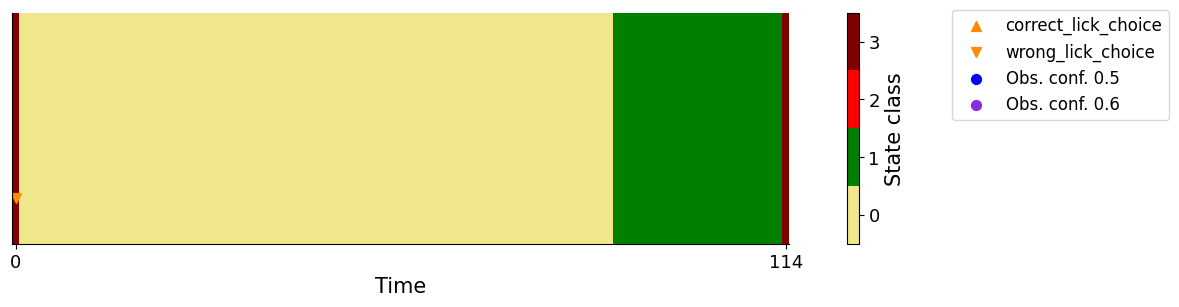

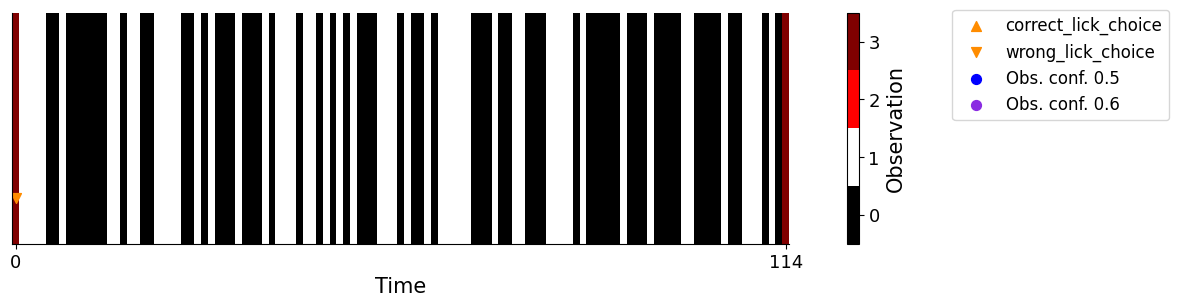

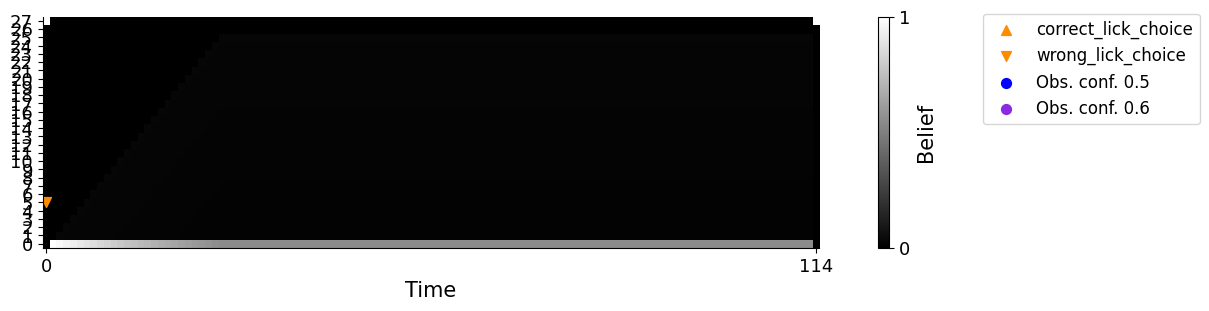

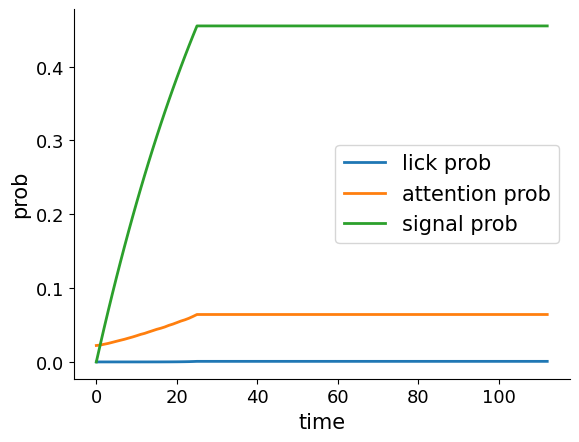

In [ ]:
episode = run_one_episode(task, taskbelief, agent,
                          num_steps=1000)
print('reward: ',food_reward_list[episode['trial_food_reward_idx']])
figs = plot_AF_episode(episode, task, agent, nodes_from_zero = 40, time_steps_before_lick = 20)

activations_list = []
for belief in episode['beliefs'][:-1]: #Last belief is not used for action
    activations_list.append(find_activation(agent, belief).numpy())
for i,f in enumerate(figs):
    quicksave(f'episode{i}', modelname,fig=f)


att_probs, lick_probs, noise_probs, time = get_att_lick_probs_new(episode, agent)
fig=plt.figure()
plt.plot(lick_probs, label = 'lick prob')
plt.plot(att_probs, label = 'attention prob')
plt.plot([1-noise_prob for noise_prob in noise_probs], label = 'signal prob')
plt.xlabel('time')
plt.ylabel('prob')
plt.legend()
plt.show()
quicksave('episode curve', modelname,fig=fig)

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_50949/1934808996.py:4: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


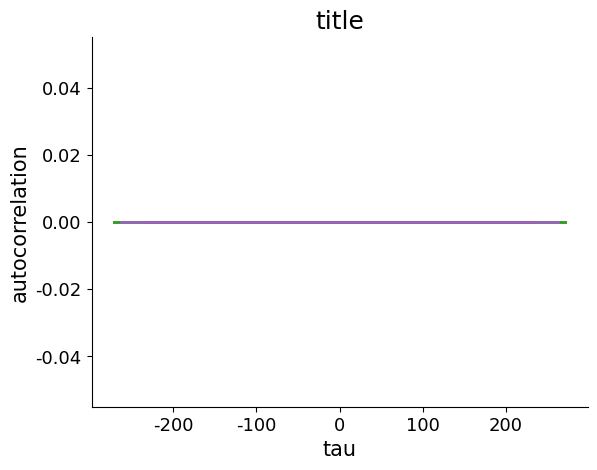

In [27]:
# auto correlation   
def compute_autocorrelation(sequence):
    autocorr = np.correlate(sequence, sequence, mode='full')
    autocorr /= np.max(autocorr)
    return autocorr
 
for food_reward_idx in range(len(food_reward_list)):
    att_seq_list = []
    for episode in all_episode_data:
        if episode['trial_food_reward_idx']==food_reward_idx:
            att_seq_list.append([float(elt[1]) for elt in episode['actions']])
    # Sorting based on increasing trial length
    sorted_list_of_lists = sorted(att_seq_list, key=len)
    sequences = sorted_list_of_lists[-1000:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
    normalized_sequences = []
    max_length = 0
    for sequence in sequences:
        normalized_seq = np.array(sequence)
        if not np.isnan(normalized_seq.any()):
            normalized_sequences.append(normalized_seq)
            max_length = max(max_length, len(normalized_seq))    
        
    padded_sequences = []
    for seq in normalized_sequences:
        padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
        padded_sequences.append(padded_seq)

    autocorrelation_sum = np.zeros(2 * max_length - 1)
    for seq in padded_sequences:
        autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)

    average_autocorrelation = autocorrelation_sum / len(padded_sequences)
    xs=np.arange(0,len(average_autocorrelation),1)
    xs=xs-len(xs)//2
    plt.plot(xs,average_autocorrelation,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
    plt.xlabel('tau')
    plt.ylabel('autocorrelation')
    plt.title('title')
quicksave('autocorr', modelname)
plt.show()


# working space

In [ ]:
attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]

no_ticks = 5
no_prob_bins = 10
min_display_time = 0
max_display_time = 50
prob_bin_vals = np.linspace(1/(2*no_prob_bins),1-1/(2*no_prob_bins),no_prob_bins)
display_tick_inds = np.linspace(0,len(prob_bin_vals) - 1,no_ticks).astype(int)

prob_bin_vals,display_tick_inds
(action_prob_list, noise_prob_list) = (lick_prob_list, noise_prob_list)
max_time = max([len(action_prob) for action_prob in action_prob_list])
max_time

prob_dict = {}
for episode_ind in range(len(noise_prob_list)):
    for time_ind in range(len(noise_prob_list[episode_ind])):
        prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)),time_ind), []).append(action_prob_list[episode_ind][time_ind])

len(noise_prob_list[episode_ind])
((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)),time_ind), [])

int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins))

noise_prob_list[episode_ind][time_ind] , no_prob_bins, episode_ind, time_ind
int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins))
prob_dict = {}
prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)),time_ind), []).append(action_prob_list[episode_ind][time_ind])
prob_dict


prob_dict = {}
for episode_ind in range(len(noise_prob_list)):
    for time_ind in range(len(noise_prob_list[episode_ind])):
        prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)),time_ind), []).append(action_prob_list[episode_ind][time_ind])

avg_action_prob_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
sem_action_prob_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
count_matrix = np.full((no_prob_bins + 1, max_time), 0.0)

avg_action_prob_matrix.shape, no_prob_bins , max_time, count_matrix.shape

for (noise_prob_bin, time_ind), action_prob_list in prob_dict.items():
    avg_action_prob_matrix[noise_prob_bin,time_ind] = np.mean(action_prob_list)
    sem_action_prob_matrix[noise_prob_bin,time_ind] = np.std(action_prob_list)/np.sqrt(len(action_prob_list))
    count_matrix[noise_prob_bin,time_ind] = len(action_prob_list)
mean_list = np.nanmean(avg_action_prob_matrix,1) # mean actionprob across timeind, for same noiseprob
sample_size_list = np.sum(count_matrix,1)
sem_list = np.nanstd(avg_action_prob_matrix,1)/np.sqrt(sample_size_list)
count_matrix.shape # (11, 188)

/tmp/ipykernel_2285224/2473173230.py:47: RuntimeWarning: Mean of empty slice
  mean_list = np.nanmean(avg_action_prob_matrix,1) # mean actionprob across timeind, for same noiseprob
/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


(11, 127)

In [28]:
# signal prob --> lick
for food_reward_idx in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]

    no_ticks = 5
    no_prob_bins = 10
    min_display_time = 0
    max_display_time = 50
    prob_bin_vals = np.linspace(1/(2*no_prob_bins),1-1/(2*no_prob_bins),no_prob_bins)
    display_tick_inds = np.linspace(0,len(prob_bin_vals) - 1,no_ticks).astype(int)

    # (action_prob_list, noise_prob_list) = (attention_prob_list, noise_prob_list)
    (action_prob_list, noise_prob_list) = (lick_prob_list, noise_prob_list)
    max_time = max([len(action_prob) for action_prob in action_prob_list])

    prob_dict = {} # (noise_prob_bin, time_ind): action_prob_list 
    for episode_ind in range(len(noise_prob_list)):
        for time_ind in range(len(noise_prob_list[episode_ind])):
            prob_dict.setdefault((int(np.floor(noise_prob_list[episode_ind][time_ind] * no_prob_bins)),time_ind), []).append(action_prob_list[episode_ind][time_ind])

    avg_action_prob_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
    sem_action_prob_matrix = np.full((no_prob_bins + 1, max_time), np.nan)
    count_matrix = np.full((no_prob_bins + 1, max_time), 0.0)
    for (noise_prob_bin, time_ind), action_prob_list in prob_dict.items():
        avg_action_prob_matrix[noise_prob_bin,time_ind] = np.mean(action_prob_list)
        sem_action_prob_matrix[noise_prob_bin,time_ind] = np.std(action_prob_list)/np.sqrt(len(action_prob_list))
        count_matrix[noise_prob_bin,time_ind] = len(action_prob_list)


    mean_list = np.nanmean(avg_action_prob_matrix,1)
    sample_size_list = np.sum(count_matrix,1)
    sem_list = np.nanstd(avg_action_prob_matrix,1)/np.sqrt(sample_size_list)


    # plt.errorbar([ind for ind in range(len(mean_list))], mean_list[::-1], yerr= sem_list[::-1], fmt='o', markersize=6, capsize=4)
    plt.plot(mean_list[::-1], 'o-', label=f'food reward={food_reward_list[food_reward_idx]:.0f}')


plt.xticks(display_tick_inds,[str(prob_bin_vals[ind])[:4] for ind in display_tick_inds])
plt.xlabel('signal prob.')
plt.ylabel('avg lick prob')
quicksave('signal prob to lick', modelname)
plt.legend()

ValueError: max() arg is an empty sequence

# extra

In [1]:
thex=food_reward_list
they=[i/(len(food_reward_list)-1) for i in range(len(food_reward_list))]

plt.plot(thex, they)
plt.ylabel('reward amount info in belief')
plt.xlabel('actual reward amount')
they

NameError: name 'food_reward_list' is not defined